# G-Objaverse: 2D Depth → 3D Point Cloud 投影

這個 notebook 展示如何從 G-Objaverse 資料集的渲染影像和深度圖，反投影回 3D 點雲。

## 核心概念
- **內參矩陣 K**: 描述相機的焦距和主點位置
- **外參矩陣 c2w (camera-to-world)**: 描述相機在世界座標系中的位姿
- **深度圖**: 每個像素到相機的距離
- **反投影公式**: `P_world = c2w @ K^(-1) @ [u, v, 1]^T * depth`

### 2D → 3D 反投影 (Unprojection)

```
給定:
- 像素座標 (u, v)
- 深度值 d
- 內參矩陣 K
- 外參矩陣 c2w (camera-to-world)

Step 1: 像素 → 相機座標
P_cam = K^(-1) @ [u, v, 1]^T * d

Step 2: 相機座標 → 世界座標  
P_world = c2w @ [P_cam, 1]^T
```

### 3D → 2D 投影 (Projection)

```
給定:
- 世界座標點 P_world = [X, Y, Z]^T
- 內參矩陣 K
- 外參矩陣 w2c (world-to-camera) = c2w^(-1)

Step 1: 世界座標 → 相機座標
P_cam = w2c @ [P_world, 1]^T

Step 2: 相機座標 → 像素座標 (透視投影)
[u', v', w'] = K @ P_cam
u = u' / w'
v = v' / w'
```

## Step 1: 載入必要的函式庫

In [1]:
import os
import cv2
import json
import os
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

# 啟用 OpenEXR 支援
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

# 設定 Hugging Face 的目錄
# os.environ["HF_HOME"] = "/mnt/ssd2/huggingface"
# os.environ["HF_HUB_CACHE"] = "/mnt/ssd2/huggingface/hub"

# ===== 選擇 GPU =====
# 改這個值來切換想用的 GPU（以 PyTorch 看到的 index 為準）
GPU_INDEX = 2          # e.g. 0: RTX 6000 Ada, 1/2: RTX PRO 6000 Blackwell, 3: RTX 3090

# 設定 matplotlib 顯示
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]

print("Libraries loaded successfully!")

if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    print(f"\n=== Available GPUs ({n_gpus}) ===")
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        mem_gb = props.total_memory / 1024**3
        marker = " <-- selected" if i == GPU_INDEX else ""
        print(f"  cuda:{i}  {props.name}  ({mem_gb:.1f} GB){marker}")

    assert GPU_INDEX < n_gpus, f"GPU_INDEX={GPU_INDEX} 超出範圍 (只有 {n_gpus} 張)"
    torch.cuda.set_device(GPU_INDEX)
    device = torch.device(f"cuda:{GPU_INDEX}")
    print(f"\nUsing device: {device} ({torch.cuda.get_device_name(GPU_INDEX)})")
else:
    device = torch.device("cpu")
    print(f"Using device: {device}")


Libraries loaded successfully!

=== Available GPUs (4) ===
  cuda:0  NVIDIA RTX 6000 Ada Generation  (47.4 GB)
  cuda:1  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  (95.0 GB)
  cuda:2  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  (95.0 GB) <-- selected
  cuda:3  NVIDIA GeForce RTX 3090  (23.6 GB)

Using device: cuda:2 (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition)


## Step 2: 定義核心函數

In [2]:
def get_intrinsic_matrix(height, width):
    """
    獲取相機內參矩陣 K
    
    G-Objaverse 使用固定焦距 fx=fy=1422.222 (基於 1024x1024 解析度)
    主點位於影像中心
    
    K = | fx  0  cx |
        | 0  fy  cy |
        | 0   0   1 |
    """
    fx = fy = 1422.222
    res_raw = 1024
    
    # 根據實際解析度縮放焦距
    f_x = f_y = fx * height / res_raw
    cx = width / 2
    cy = height / 2
    
    K = np.array([
        [f_x, 0, cx],
        [0, f_y, cy],
        [0, 0, 1]
    ], dtype=np.float32)
    
    return K


def read_camera_matrix(json_file):
    """
    讀取相機外參矩陣 (camera-to-world, c2w)
    
    JSON 檔案包含:
    - x: 相機 X 軸方向 (right)
    - y: 相機 Y 軸方向 (up)
    - z: 相機 Z 軸方向 (forward/backward)
    - origin: 相機位置
    
    注意: 需要 flip Y 和 Z 軸來轉換座標系統
    """
    with open(json_file, 'r', encoding='utf8') as f:
        data = json.load(f)
    
    c2w = np.eye(4, dtype=np.float32)
    c2w[:3, 0] = np.array(data['x'])       # X 軸
    c2w[:3, 1] = -np.array(data['y'])      # Y 軸 (flipped)
    c2w[:3, 2] = -np.array(data['z'])      # Z 軸 (flipped)
    c2w[:3, 3] = np.array(data['origin'])  # 相機位置
    
    return c2w


def read_depth_from_exr(exr_path, camera_position):
    """
    從 EXR 檔案讀取深度圖
    
    *_nd.exr 檔案格式:
    - Channel 0-2: Normal (世界座標系)
    - Channel 3: Depth
    
    深度值需要過濾掉 near plane 之前的無效值
    """
    # 計算相機距離原點的距離
    cam_distance = np.linalg.norm(camera_position)
    
    # near plane 設定 (物體被normalize到單位球內)
    near = 0.867  # sqrt(3) * 0.5
    near_distance = cam_distance - near
    
    # 讀取 EXR 檔案
    normald = cv2.imread(exr_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth = normald[..., 3]  # 第4個通道是深度
    
    # 過濾無效深度值
    depth[depth < near_distance] = 0
    
    return depth, normald[..., :3]  # 回傳深度和法向量


def read_rgb_image(img_path):
    """讀取 RGB 影像並轉換到 [0, 1] 範圍"""
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")
    
    # BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 處理 RGBA
    if img.shape[-1] == 4:
        img = img[..., :3]
    
    return img.astype(np.float32) / 255.0

print("Core functions defined!")

Core functions defined!


## Step 3: 2D → 3D 反投影函數 (核心！)

In [3]:
def unproject_depth_to_pointcloud(depth, K, c2w, rgb=None):
    """
    將深度圖反投影到 3D 世界座標點雲
    
    數學公式:
    1. 像素座標 (u, v) + depth → 相機座標 P_cam
       P_cam = K^(-1) @ [u, v, 1]^T * depth
    
    2. 相機座標 → 世界座標
       P_world = c2w @ [P_cam, 1]^T
    
    Args:
        depth: [H, W] 深度圖
        K: [3, 3] 內參矩陣
        c2w: [4, 4] camera-to-world 矩陣
        rgb: [H, W, 3] 可選的顏色圖
    
    Returns:
        points: [N, 3] 世界座標點雲
        colors: [N, 3] 對應的顏色 (如果有提供 rgb)
    """
    H, W = depth.shape
    
    # Step 1: 建立像素座標網格
    u = np.arange(W)
    v = np.arange(H)
    u, v = np.meshgrid(u, v)  # [H, W]
    
    # Step 2: 只取有效深度的點
    valid_mask = depth > 0
    u_valid = u[valid_mask]
    v_valid = v[valid_mask]
    depth_valid = depth[valid_mask]
    
    # Step 3: 像素座標 → 齊次座標
    # [u, v, 1]^T
    ones = np.ones_like(u_valid)
    pixel_coords = np.stack([u_valid, v_valid, ones], axis=0)  # [3, N]
    
    # Step 4: 反投影到相機座標系
    # P_cam = K^(-1) @ [u, v, 1]^T * depth
    K_inv = np.linalg.inv(K)
    cam_coords = K_inv @ pixel_coords  # [3, N]
    cam_coords = cam_coords * depth_valid[np.newaxis, :]  # 乘以深度
    
    # Step 5: 相機座標 → 世界座標
    # P_world = c2w @ [P_cam, 1]^T
    ones_row = np.ones((1, cam_coords.shape[1]))
    cam_coords_homo = np.vstack([cam_coords, ones_row])  # [4, N]
    world_coords = c2w @ cam_coords_homo  # [4, N]
    points = world_coords[:3, :].T  # [N, 3]
    
    # Step 6: 獲取顏色
    colors = None
    if rgb is not None:
        colors = rgb[valid_mask]  # [N, 3]
    
    return points, colors, valid_mask


def convert_pose_flip_yz(c2w):
    """
    Flip Y 和 Z 軸 (用於座標系統轉換)
    這是因為不同軟體使用不同的座標系統慣例
    """
    flip_yz = np.eye(4)
    flip_yz[1, 1] = -1
    flip_yz[2, 2] = -1
    return c2w @ flip_yz

print("Unprojection functions defined!")

Unprojection functions defined!


## Step 4: 設定資料路徑

In [4]:
# ===== 修改這裡的路徑 =====
# 下載範例資料: wget https://virutalbuy-public.oss-cn-hangzhou.aliyuncs.com/share/Lingtengqiu/render_data_examples.zip
DATA_ROOT = './dataset/gobjaverse/electronics/10/62950'  # 範例資料路徑

# 檢查路徑是否存在
if os.path.exists(DATA_ROOT):
    view_folders = sorted([f for f in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, f))])
    print(f"✅ Found {len(view_folders)} views in {DATA_ROOT}")
    print(f"  Views: {view_folders[:5]}... (showing first 5)")
else:
    print(f"❌ Path not found: {DATA_ROOT}")
    print("請下載範例資料或修改 DATA_ROOT 路徑")
    print("下載指令: wget https://virutalbuy-public.oss-cn-hangzhou.aliyuncs.com/share/Lingtengqiu/render_data_examples.zip")

✅ Found 40 views in ./dataset/gobjaverse/electronics/10/62950
  Views: ['00000', '00001', '00002', '00003', '00004']... (showing first 5)


## Step 5: 讀取單一視角的資料並視覺化

Loading view 0...
  RGB: ./dataset/gobjaverse/electronics/10/62950/00000/00000.png
  Depth: ./dataset/gobjaverse/electronics/10/62950/00000/00000_nd.exr
  Camera: ./dataset/gobjaverse/electronics/10/62950/00000/00000.json

Camera position: [1.6940895  0.         0.65048367]
Camera distance from origin: 1.815

Image shape: (512, 512, 3)
Depth shape: (512, 512)
Depth range: [0.949, 1.846]


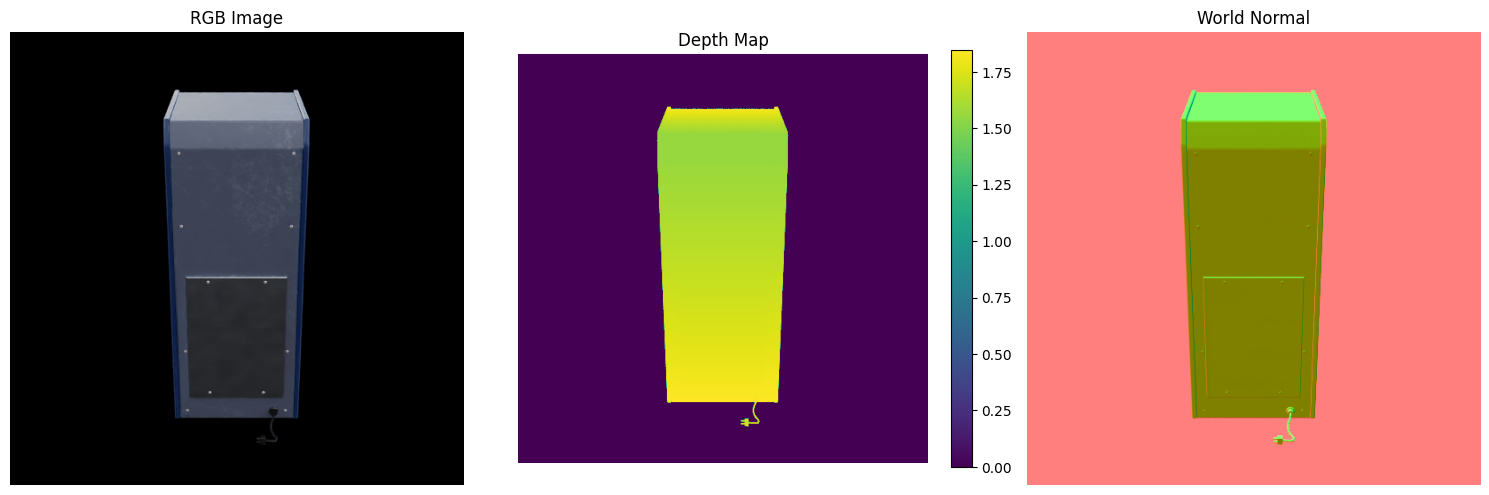

In [5]:
# 選擇要讀取的視角
VIEW_IDX = 0

# 建立檔案路徑
img_path = f'{DATA_ROOT}/{VIEW_IDX:05d}/{VIEW_IDX:05d}.png'
depth_path = f'{DATA_ROOT}/{VIEW_IDX:05d}/{VIEW_IDX:05d}_nd.exr'
json_path = f'{DATA_ROOT}/{VIEW_IDX:05d}/{VIEW_IDX:05d}.json'

print(f"Loading view {VIEW_IDX}...")
print(f"  RGB: {img_path}")
print(f"  Depth: {depth_path}")
print(f"  Camera: {json_path}")

# 讀取相機參數
c2w = read_camera_matrix(json_path)
camera_position = c2w[:3, 3]

print(f"\nCamera position: {camera_position}")
print(f"Camera distance from origin: {np.linalg.norm(camera_position):.3f}")

# 讀取 RGB 和深度
rgb = read_rgb_image(img_path)
depth, normal = read_depth_from_exr(depth_path, camera_position)

print(f"\nImage shape: {rgb.shape}")
print(f"Depth shape: {depth.shape}")
print(f"Depth range: [{depth[depth>0].min():.3f}, {depth[depth>0].max():.3f}]")

# 視覺化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb)
axes[0].set_title('RGB Image')
axes[0].axis('off')

im = axes[1].imshow(depth, cmap='viridis')
axes[1].set_title('Depth Map')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# 法向量視覺化 (轉換到 [0, 1] 範圍)
normal_vis = (normal + 1) / 2
normal_vis = np.clip(normal_vis, 0, 1)
axes[2].imshow(normal_vis)
axes[2].set_title('World Normal')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Step 6: 將單一視角反投影到 3D 點雲

In [6]:
# 獲取內參矩陣
H, W = depth.shape
K = get_intrinsic_matrix(H, W)

print("Intrinsic Matrix K:")
print(K)
print(f"\nFocal length: fx={K[0,0]:.2f}, fy={K[1,1]:.2f}")
print(f"Principal point: cx={K[0,2]:.2f}, cy={K[1,2]:.2f}")

# 執行反投影
c2w_converted = convert_pose_flip_yz(c2w)
points, colors, valid_mask = unproject_depth_to_pointcloud(depth, K, c2w_converted, rgb)

print(f"\nGenerated {len(points)} 3D points")
print(f"Point cloud bounds:")
print(f"  X: [{points[:, 0].min():.3f}, {points[:, 0].max():.3f}]")
print(f"  Y: [{points[:, 1].min():.3f}, {points[:, 1].max():.3f}]")
print(f"  Z: [{points[:, 2].min():.3f}, {points[:, 2].max():.3f}]")

Intrinsic Matrix K:
[[711.111   0.    256.   ]
 [  0.    711.111 256.   ]
 [  0.      0.      1.   ]]

Focal length: fx=711.11, fy=711.11
Principal point: cx=256.00, cy=256.00

Generated 56005 3D points
Point cloud bounds:
  X: [-0.193, 0.886]
  Y: [-0.181, 0.176]
  Z: [-0.444, 0.543]


## Step 7: 視覺化單視角 3D 點雲

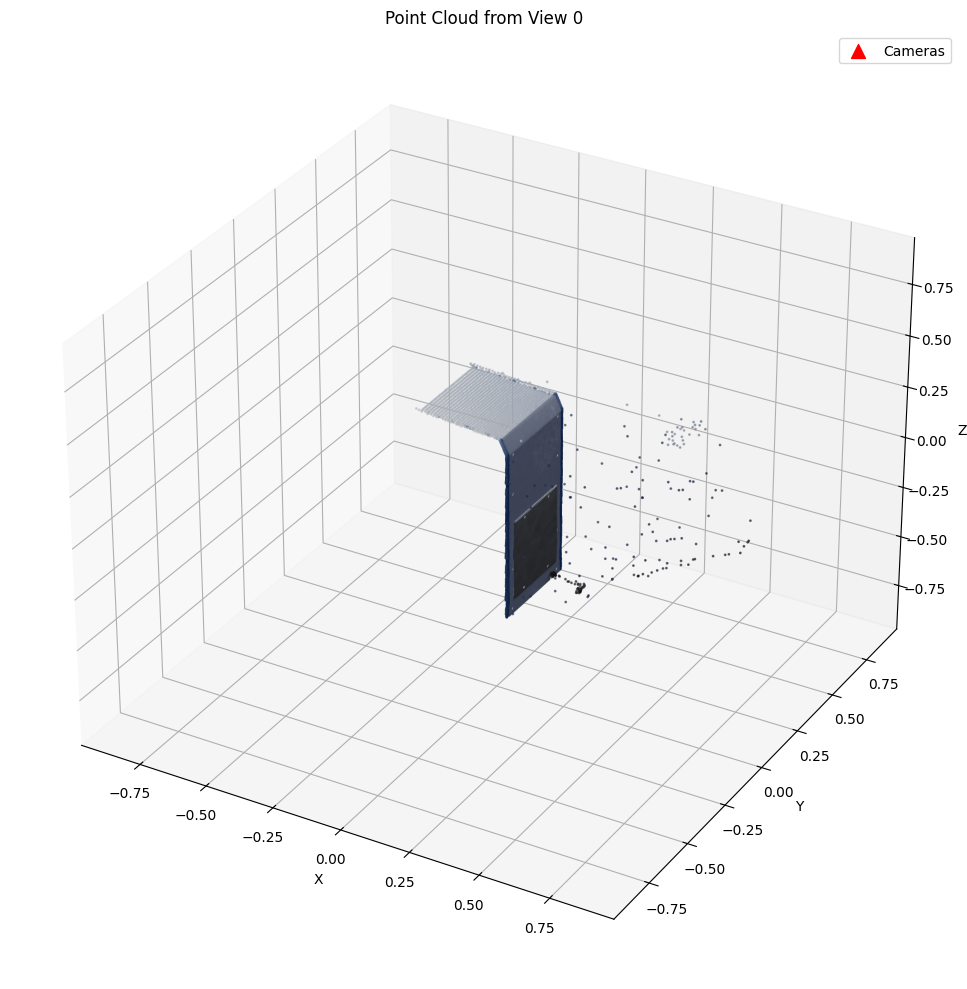

In [7]:
def visualize_point_cloud_3d(points, colors=None, title="Point Cloud", 
                              camera_positions=None, subsample=5):
    """
    使用 matplotlib 視覺化 3D 點雲
    
    Args:
        points: [N, 3] 點雲座標
        colors: [N, 3] 點的顏色
        camera_positions: list of [3,] 相機位置 (可選)
        subsample: 降採樣倍率 (加速視覺化)
    """
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Downsampling 以加速視覺化
    idx = np.arange(0, len(points), subsample)
    pts = points[idx]
    
    if colors is not None:
        cols = colors[idx]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], 
                   c=cols, s=1, alpha=0.6)
    else:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], 
                   s=1, alpha=0.6)
    
    # 繪製相機位置
    if camera_positions is not None:
        cam_pos = np.array(camera_positions)
        ax.scatter(cam_pos[:, 0], cam_pos[:, 1], cam_pos[:, 2],
                   c='red', s=100, marker='^', label='Cameras')
        ax.legend()
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    # 設定相等的軸比例
    max_range = np.max(np.abs(pts)) * 1.1
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    
    plt.tight_layout()
    return fig, ax

# 視覺化單視角點雲
fig, ax = visualize_point_cloud_3d(
    points, colors, 
    title=f"Point Cloud from View {VIEW_IDX}",
    camera_positions=[camera_position],
    subsample=3
)
plt.show()

## Step 8: 合併多個視角的點雲

In [8]:
def load_all_views(data_root, num_views=40):
    """
    載入所有視角的資料並合併成完整點雲
    
    Args:
        data_root: 資料根目錄
        num_views: 視角數量 (預設 40)
    
    Returns:
        all_points: 合併的點雲
        all_colors: 對應的顏色
        camera_positions: 所有相機位置
    """
    all_points = []
    all_colors = []
    camera_positions = []
    
    for view_idx in tqdm.trange(num_views, desc=f"Loading {num_views} views"):
        # 檔案路徑
        img_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}.png'
        depth_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}_nd.exr'
        json_path = f'{data_root}/{view_idx:05d}/{view_idx:05d}.json'
        
        # 檢查檔案是否存在
        if not all(os.path.exists(p) for p in [img_path, depth_path, json_path]):
            print(f"  Skipping view {view_idx} (files not found)")
            continue
        
        # 讀取資料
        c2w = read_camera_matrix(json_path)
        camera_pos = c2w[:3, 3]
        
        rgb = read_rgb_image(img_path)
        depth, _ = read_depth_from_exr(depth_path, camera_pos)
        
        # 內參
        H, W = depth.shape
        K = get_intrinsic_matrix(H, W)
        
        # 反投影
        c2w_converted = convert_pose_flip_yz(c2w)
        points, colors, _ = unproject_depth_to_pointcloud(depth, K, c2w_converted, rgb)
        
        all_points.append(points)
        all_colors.append(colors)
        camera_positions.append(camera_pos)
    
    # 合併
    all_points = np.vstack(all_points)
    all_colors = np.vstack(all_colors)
    camera_positions = np.array(camera_positions)
    
    return all_points, all_colors, camera_positions


# 載入多個視角 (這裡只載入前 8 個視角作為示範，可調整)
NUM_VIEWS_TO_LOAD = 24  # 可以改成 40 載入所有視角

all_points, all_colors, all_camera_positions = load_all_views(DATA_ROOT, NUM_VIEWS_TO_LOAD)

print(f"\n=== Summary ===")
print(f"Total cameras: {len(all_camera_positions)}, Total points: {len(all_points):,}")

Loading 24 views: 100%|██████████| 24/24 [00:09<00:00,  2.61it/s]


=== Summary ===
Total cameras: 24, Total points: 1,508,429


## Step 9: 視覺化合併後的完整點雲

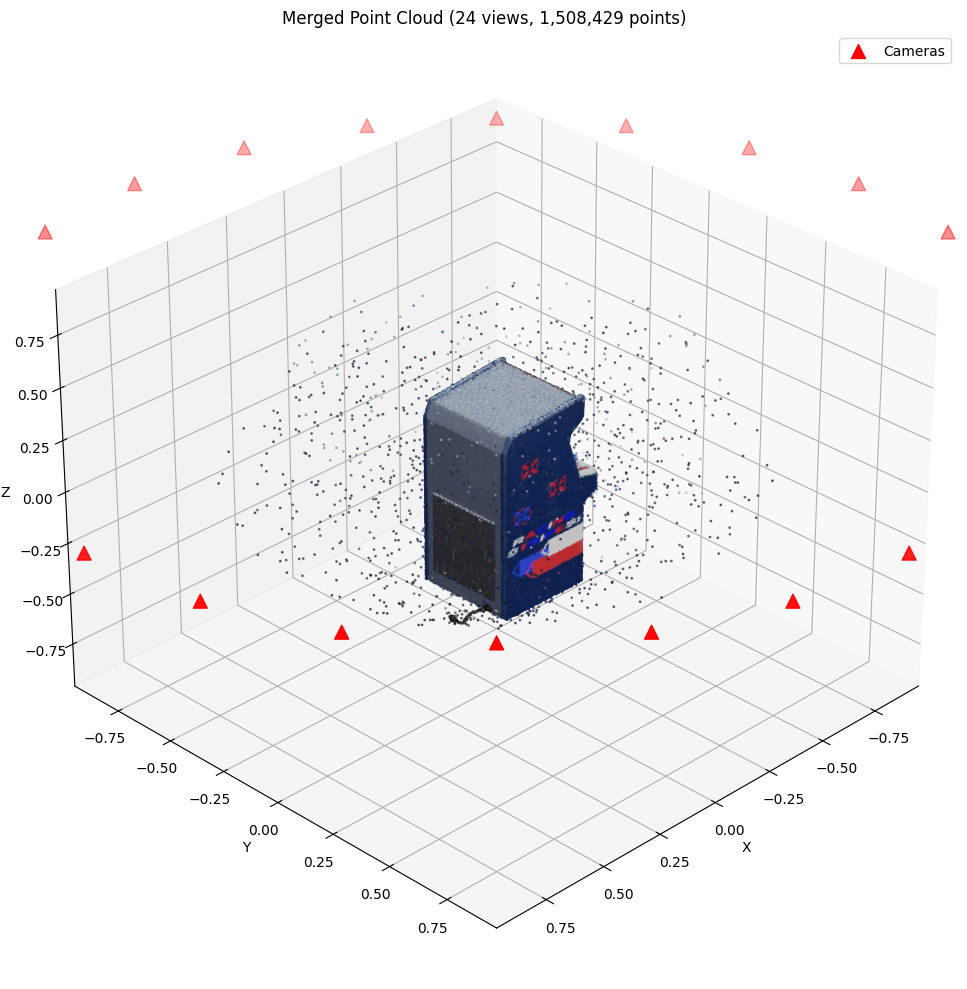

In [9]:
# 視覺化完整點雲
fig, ax = visualize_point_cloud_3d(
    all_points, all_colors,
    title=f"Merged Point Cloud ({NUM_VIEWS_TO_LOAD} views, {len(all_points):,} points)",
    camera_positions=all_camera_positions,
    subsample=10  # 降採樣倍率
)

# 可以旋轉視角
ax.view_init(elev=30, azim=45)
plt.show()

## Step 10: 互動式 3D 視覺化 (使用 plotly)

In [10]:
# # 可選: 使用 plotly 進行互動式視覺化
# try:
#     import plotly.graph_objects as go
    
#     # 降採樣
#     subsample = 20
#     idx = np.arange(0, len(all_points), subsample)
#     pts = all_points[idx]
#     cols = all_colors[idx]
    
#     # 將顏色轉換為 plotly 格式
#     colors_rgb = ['rgb({},{},{})'.format(int(c[0]*255), int(c[1]*255), int(c[2]*255)) 
#                   for c in cols]
    
#     fig = go.Figure()
    
#     # 點雲
#     fig.add_trace(go.Scatter3d(
#         x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
#         mode='markers',
#         marker=dict(size=1, color=colors_rgb),
#         name='Point Cloud'
#     ))
    
#     # 相機位置
#     fig.add_trace(go.Scatter3d(
#         x=all_camera_positions[:, 0],
#         y=all_camera_positions[:, 1],
#         z=all_camera_positions[:, 2],
#         mode='markers',
#         marker=dict(size=5, color='red', symbol='diamond'),
#         name='Cameras'
#     ))
    
#     fig.update_layout(
#         title=f"Interactive Point Cloud ({len(pts):,} points displayed)",
#         scene=dict(
#             aspectmode='data',
#             xaxis_title='X',
#             yaxis_title='Y',
#             zaxis_title='Z'
#         ),
#         width=900,
#         height=700
#     )
    
#     fig.show()
    
# except ImportError:
#     print("Plotly not installed. Run: pip install plotly")
#     print("Skipping interactive visualization.")

---

# Affogato Pipeline: Molmo → SAM2 → 3D Affordance Heatmap

接下來我們要實作 **Affogato** 的核心 pipeline：

1. **Step 12**: 顯示 24 view images 的 grid
2. **Step 13**: 載入 Molmo VLM，對每張 view 做 affordance query，取得 2D 標註點
3. **Step 14**: 用 Molmo 的標註點作為 SAM2 的 point prompt，產生 mask → sigmoid → probabilistic heatmap
4. **Step 15**: 把 24 view 的 heatmap 反投影回 3D point cloud，取交集得到 3D affordance heatmap

## Step 11: 顯示 24 個 View Images

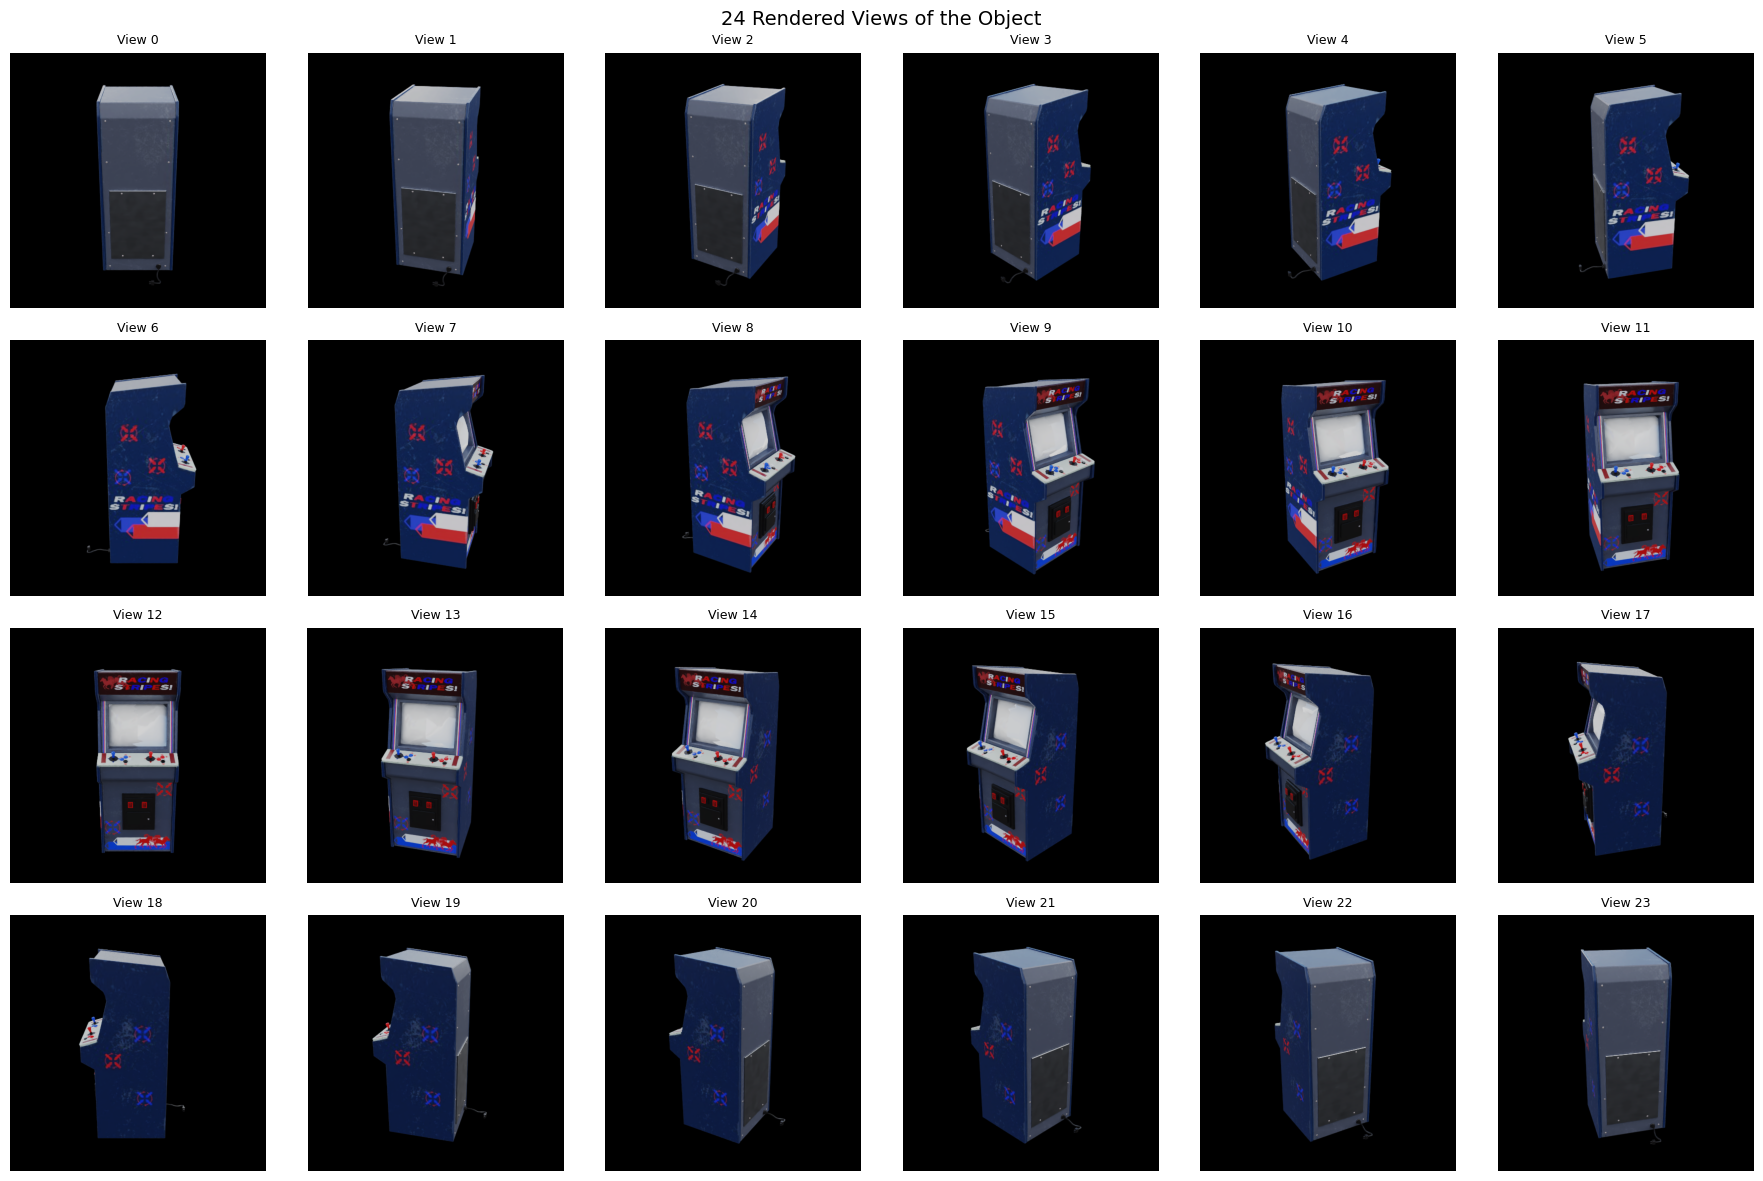

Loaded 24 view images, size: (512, 512)


In [11]:
# 載入並顯示所有 24 view 的 RGB 影像
from PIL import Image

view_images = []       # 存放 PIL Image (給後續 Molmo / SAM2 使用)
view_images_np = []    # numpy 格式

for view_idx in range(NUM_VIEWS_TO_LOAD):
    img_path = f'{DATA_ROOT}/{view_idx:05d}/{view_idx:05d}.png'
    img = Image.open(img_path).convert('RGB')                      # 讀取為 PIL Image, 並確保是 RGB 模式
    view_images.append(img)         
    view_images_np.append(np.array(img))                           # 存成 numpy 格式以便 matplotlib 顯示

# 畫 grid: 4 rows x 6 cols
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
for i, ax in enumerate(axes.flat):
    if i < len(view_images_np):
        ax.imshow(view_images_np[i])
        ax.set_title(f'View {i}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'{NUM_VIEWS_TO_LOAD} Rendered Views of the Object', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Loaded {len(view_images)} view images, size: {view_images[0].size}")

## Step 12: 使用 Molmo2 VLM 標註 Affordance 點

Molmo2 是 Allen AI 開發的 Vision-Language Model (基於 Qwen3-8B)，具有 **pointing** 能力——
給它一個自然語言 query（例如 "Point to where you would grab this mug"），它會輸出圖上對應的 (x, y) 座標。

**輸出格式**: Molmo2 輸出 `<points coords="frame_id idx x y ..."/>` 格式，
座標是千分比 (0-1000)，需要除以 1000 再乘以影像尺寸轉換成像素座標。

In [12]:
import gc
import re
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

# ====== 設定 ======
MOLMO_MODEL_ID = "allenai/MolmoPoint-8B"

# ROLE_QUERIES: 每個 role 一個 Molmo prompt（每個 role 各跑一次推論）
# Role 名稱用功能角色（move / action / support / actuate），不要用 left / right。
# Prompt 模板與 fallback 策略見 prompt/molmo_prompt_format.md
#
# === Default: 當前 asset 是 playing machine (arcade-style, joystick + button) ===
# 用 part-name (Template B) 而非 action-verb (Template A) — 兩 role 部位在空間上接近
# (joystick 緊鄰 action button) 時 verb-based prompt 兩個 query 容易塌到同一個顯著部位。
# 詳見 prompt/molmo_prompt_format.md 與 notes/role_query_disambiguation.md
ROLE_QUERIES = {
    "role_move":   "Point to the joystick on this arcade machine.",
    "role_action": "Point to the action button on this arcade machine.",
}

# === 其他物件範例（取消註解切換）===
# Bottle (twist-open)
# ROLE_QUERIES = {
#     "role_support": "Point to where you would grip to hold the bottle steady.",
#     "role_actuate": "Point to where you would twist to open the cap.",
# }
# Drawer
# ROLE_QUERIES = {
#     "role_support": "Point to where you would hold the drawer body steady.",
#     "role_actuate": "Point to where you would pull to open the drawer.",
# }
# Mug (pouring)
# ROLE_QUERIES = {
#     "role_support": "Point to where you would grip the handle.",
#     "role_actuate": "Point to where you would tilt the rim to pour.",
# }

ROLES = list(ROLE_QUERIES.keys())

# Per-role 視覺化用的顏色（後續 cell 用到）
_DEFAULT_COLORS = ["red", "deepskyblue", "lime", "orange", "magenta"]
_DEFAULT_SCALES = ["Reds", "Blues", "Greens", "Oranges", "Purples"]
ROLE_COLORS      = {r: _DEFAULT_COLORS[i % len(_DEFAULT_COLORS)] for i, r in enumerate(ROLES)}
ROLE_COLORSCALES = {r: _DEFAULT_SCALES[i % len(_DEFAULT_SCALES)] for i, r in enumerate(ROLES)}

print(f"Roles: {ROLES}")
for role, q in ROLE_QUERIES.items():
    print(f"  [{role}] -> {q}")

# ====== 載入 Molmo2 ======
print(f"\nLoading Molmo2 model: {MOLMO_MODEL_ID} ...")
molmo_processor = AutoProcessor.from_pretrained(
    MOLMO_MODEL_ID,
    trust_remote_code=True,
)
molmo_model = AutoModelForImageTextToText.from_pretrained(
    MOLMO_MODEL_ID,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
print("Molmo2 loaded!")

I0000 00:00:1778001769.674869 1807609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778001769.780577 1807609 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Roles: ['role_move', 'role_action']
  [role_move] -> Point to the joystick on this arcade machine.
  [role_action] -> Point to the action button on this arcade machine.

Loading Molmo2 model: allenai/MolmoPoint-8B ...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
<unknown>:62: SyntaxWarning: invalid escape sequence '\d'


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Molmo2 loaded!


In [13]:
# MolmoPoint-8B: 從已載入的模型模組中取得 extract_image_points
_molmo_module = type(molmo_model).__module__
_mod = __import__(_molmo_module, fromlist=['extract_image_points'])
extract_image_points = _mod.extract_image_points
print(f"Loaded extract_image_points from {_molmo_module}")


def molmo_query_image(img, query_text):
    """對單張 image 跑一次 Molmo pointing。回傳 (top1_point_list, raw_text)。
    Molmo 上游對 pointing batch>1 有多處 bug (Python `and` on tensor / 錯誤 broadcast / RoPE size mismatch)，
    所以這邊維持 single-image inference。"""
    messages = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": query_text},
    ]}]
    prompt_text = molmo_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = molmo_processor(
        text=prompt_text,
        images=[img],
        return_pointing_metadata=True,
        return_tensors="pt",
    )
    metadata = inputs.pop("metadata")
    inputs = {k: v.to(molmo_model.device) for k, v in inputs.items()}

    with torch.inference_mode(), torch.amp.autocast('cuda', dtype=torch.bfloat16):
        generated_ids = molmo_model.generate(**inputs, max_new_tokens=200)

    generated_tokens = generated_ids[0, inputs['input_ids'].size(1):]
    generated_text = molmo_processor.tokenizer.decode(generated_tokens, skip_special_tokens=False)

    extracted = extract_image_points(
        output_text=generated_text,
        pooling=metadata["token_pooling"],
        mappings=metadata["subpatch_mapping"],
        no_more_points_class=molmo_model.config.no_more_points_class,
        location=molmo_model.config.patch_location is not None,
        image_sizes=metadata["image_sizes"],
    )
    # Molmo 解碼順序即 confidence 順序，只保留最強的一個
    if len(extracted) > 0:
        _, _, x, y = extracted[0]
        pts = [np.array([x, y])]
    else:
        pts = []

    del inputs, generated_ids, generated_tokens
    gc.collect()
    torch.cuda.empty_cache()

    return pts, generated_text


# ====== Per-role × per-view: 跑 Molmo affordance query (top-1 per role) ======
molmo_points_per_view_per_role = {role: [[] for _ in range(len(view_images))] for role in ROLES}
molmo_raw_outputs_per_role     = {role: [""] * len(view_images)              for role in ROLES}

for role in ROLES:
    query_text = ROLE_QUERIES[role]
    print(f"\n=== Role: {role} ===\nQuery: {query_text}")

    for view_idx in tqdm.trange(len(view_images), desc=f"MolmoPoint [{role}]"):
        pts, raw = molmo_query_image(view_images[view_idx], query_text)
        molmo_points_per_view_per_role[role][view_idx] = pts
        molmo_raw_outputs_per_role[role][view_idx]     = raw

    n_views_with = sum(1 for p in molmo_points_per_view_per_role[role] if len(p) > 0)
    n_pts = sum(len(p) for p in molmo_points_per_view_per_role[role])
    print(f"  → views with points: {n_views_with}/{len(view_images)}, total points: {n_pts}")

Loaded extract_image_points from transformers_modules.allenai.MolmoPoint_hyphen_8B.188130f961c8e0888a34e11121a1423c461a01ba.modeling_molmo_point

=== Role: role_move ===
Query: Point to the joystick on this arcade machine.


MolmoPoint [role_move]: 100%|██████████| 24/24 [00:43<00:00,  1.80s/it]


  → views with points: 16/24, total points: 16

=== Role: role_action ===
Query: Point to the action button on this arcade machine.


MolmoPoint [role_action]: 100%|██████████| 24/24 [00:54<00:00,  2.28s/it]

  → views with points: 23/24, total points: 23


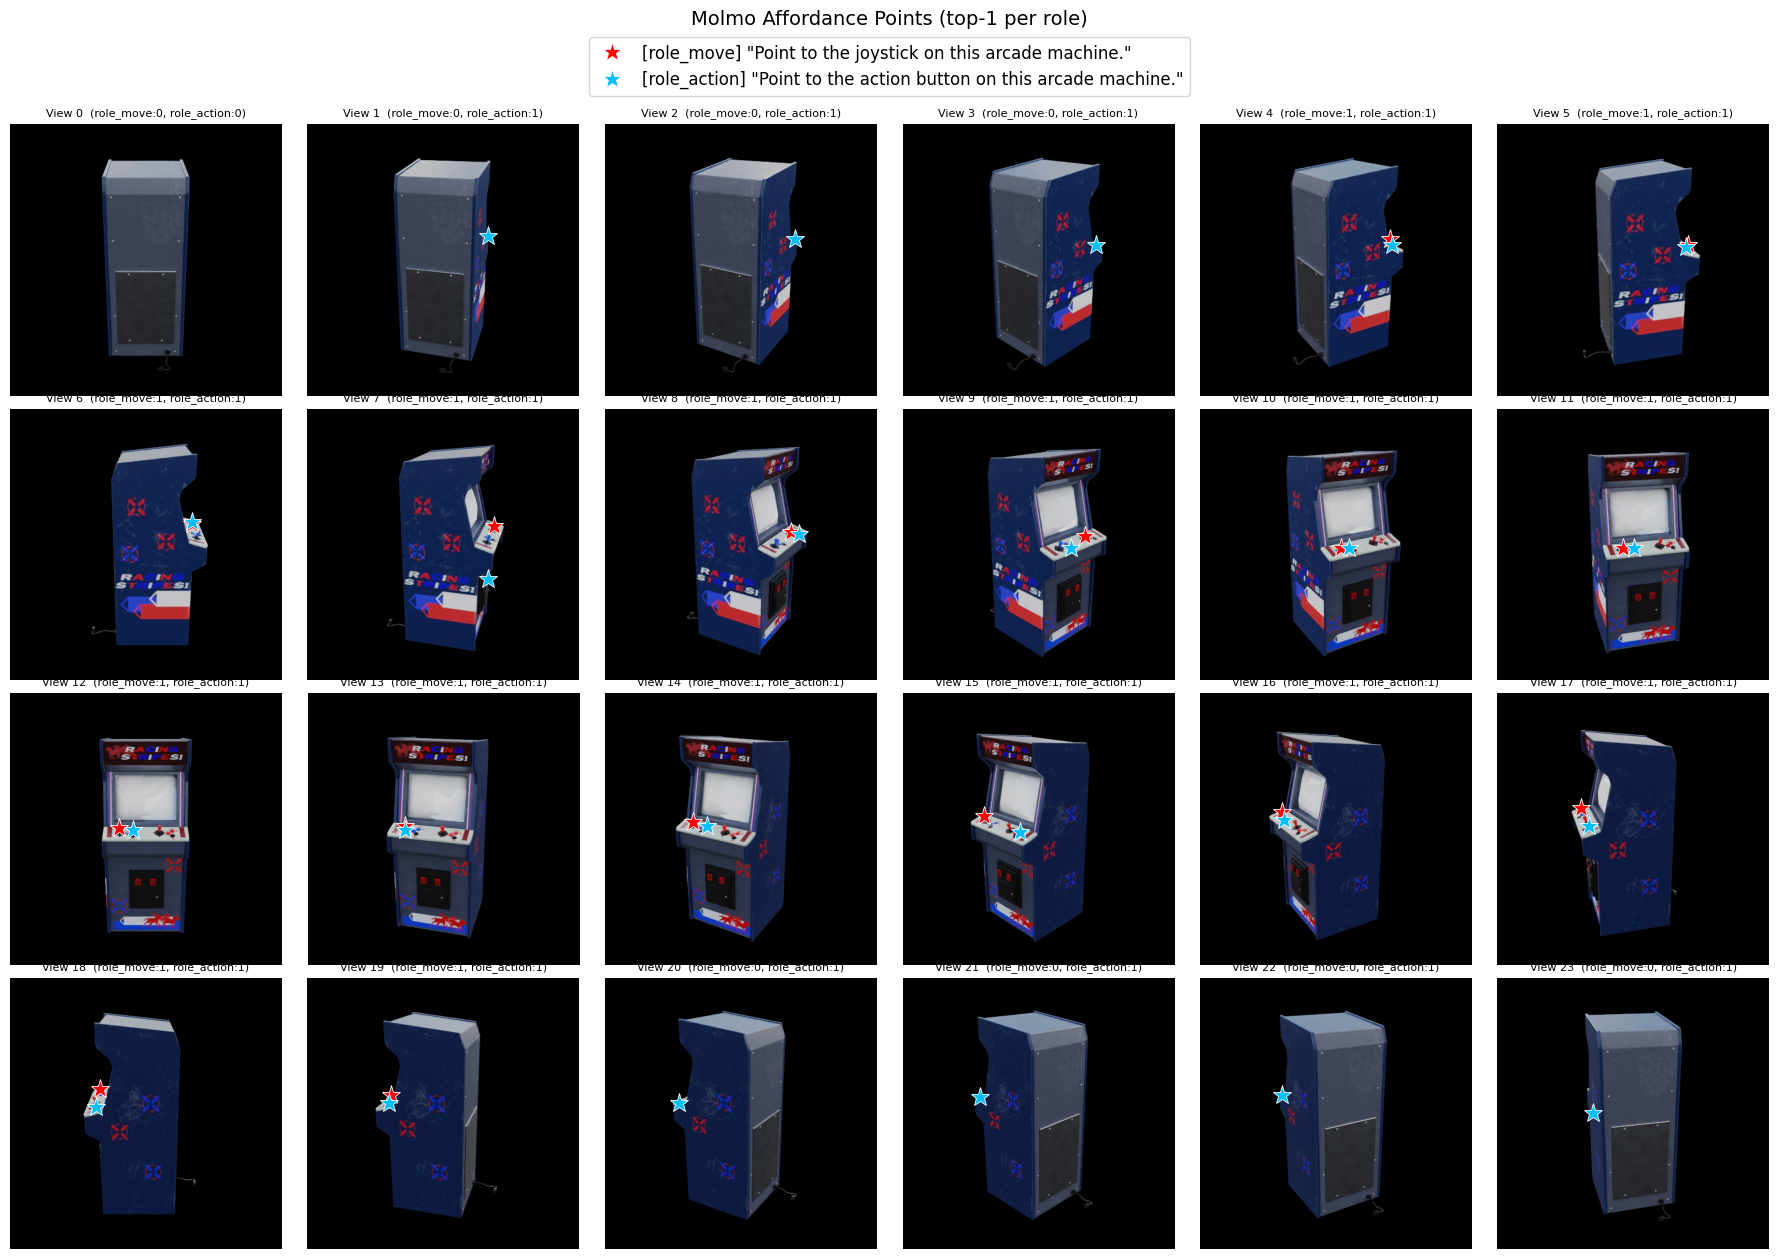

In [14]:
# 視覺化: 在同一組 grid 上畫所有 role 的點 (top-1 per role)，
#         以 ROLE_COLORS 區分，legend 標註對應的 query
from matplotlib.lines import Line2D

fig, axes = plt.subplots(4, 6, figsize=(18, 13))

for i, ax in enumerate(axes.flat):
    if i < len(view_images_np):
        ax.imshow(view_images_np[i])
        for role in ROLES:
            pts = molmo_points_per_view_per_role[role][i]
            for pt in pts:
                ax.plot(pt[0], pt[1], '*', markersize=14,
                        c=ROLE_COLORS[role],
                        markeredgecolor='white', markeredgewidth=0.6)
        counts = ", ".join(
            f'{role}:{len(molmo_points_per_view_per_role[role][i])}' for role in ROLES
        )
        ax.set_title(f'View {i}  ({counts})', fontsize=8)
    ax.axis('off')

# 一個 legend，把 query 文字也帶上
legend_handles = [
    Line2D([0], [0], marker='*', linestyle='None',
           markerfacecolor=ROLE_COLORS[role],
           markeredgecolor='white', markeredgewidth=0.6,
           markersize=14,
           label=f'[{role}] "{ROLE_QUERIES[role]}"')
    for role in ROLES
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.95),
    ncol=1,
    fontsize=12,
    frameon=True,
)

plt.suptitle("Molmo Affordance Points (top-1 per role)", fontsize=14, y=0.965)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Step 13: SAM2 Point Prompt → Mask → Probabilistic Heatmap

使用 Molmo 預測的點作為 **SAM2 的 point prompt**：
1. `SAM2ImagePredictor.set_image(image)` 計算 image embedding
2. `predict(point_coords, point_labels, return_logits=True)` 取得 **mask logits** (未經 threshold)
3. 對 logits 做 **sigmoid** 壓縮到 [0, 1]，得到 probabilistic heatmap

> 為什麼要用 logits 而不是 binary mask？因為我們最終要把多個 view 的信心值合在一起做交集，
> binary mask 會丟失 "多有信心" 的資訊。

In [15]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ====== 載入 SAM2 ======
# 若使用 HuggingFace 預訓練權重:
#   sam2_predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large")
# 若本地下載了 checkpoint:

SAM2_CHECKPOINT = "checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
print(f"Loading SAM2: {SAM2_CHECKPOINT} ...")

sam2_model = build_sam2(model_cfg, SAM2_CHECKPOINT, device=device)
sam2_predictor = SAM2ImagePredictor(sam2_model)
print("SAM2 loaded!")

Loading SAM2: checkpoints/sam2.1_hiera_large.pt ...
SAM2 loaded!


In [16]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def make_gaussian_weight(H, W, points, sigma=50):
    """
    建立以 Molmo 點為中心的 Gaussian weight map。
    多個點取 max（union of Gaussians）。sigma 越小越聚焦。
    """
    u = np.arange(W)[np.newaxis, :]  # [1, W]
    v = np.arange(H)[:, np.newaxis]  # [H, 1]

    weight = np.zeros((H, W), dtype=np.float32)
    for pt in points:
        dx = u - pt[0]
        dy = v - pt[1]
        g = np.exp(-(dx**2 + dy**2) / (2 * sigma**2))
        weight = np.maximum(weight, g)
    return weight


# ====== 參數設定 ======
GAUSSIAN_SIGMA = 77             # Gaussian 半徑 (像素)
MASK_SELECT = "best_iou"        # "smallest" or "best_iou"

# ====== Per-role × per-view: Molmo 點 → SAM2 mask logits → Gaussian-weighted heatmap ======
heatmaps_per_view_per_role = {role: [] for role in ROLES}

for role in ROLES:
    print(f"\n=== SAM2 heatmaps for [{role}]  (mask={MASK_SELECT}, sigma={GAUSSIAN_SIGMA}) ===")
    points_per_view = molmo_points_per_view_per_role[role]

    for view_idx in tqdm.trange(len(view_images), desc=f"Heatmaps [{role}]"):
        points = points_per_view[view_idx]
        img_np = view_images_np[view_idx]

        if len(points) == 0:
            H, W = img_np.shape[:2]
            heatmaps_per_view_per_role[role].append(np.zeros((H, W), dtype=np.float32))
            continue

        sam2_predictor.set_image(img_np)

        point_coords = np.array(points, dtype=np.float32)
        point_labels = np.ones(len(points), dtype=np.int32)

        masks, iou_scores, low_res_logits = sam2_predictor.predict(
            point_coords=point_coords,
            point_labels=point_labels,
            multimask_output=True,
            return_logits=True,
        )

        if MASK_SELECT == "smallest":
            mask_areas = [(m > 0).sum() for m in masks]
            best_idx = np.argmin(mask_areas)
        else:
            best_idx = np.argmax(iou_scores)

        best_logits = masks[best_idx]
        heatmap = sigmoid(best_logits).astype(np.float32)

        H, W = img_np.shape[:2]
        gauss_w = make_gaussian_weight(H, W, points, sigma=GAUSSIAN_SIGMA)
        heatmap = heatmap * gauss_w

        heatmaps_per_view_per_role[role].append(heatmap)
        sam2_predictor.reset_predictor()


=== SAM2 heatmaps for [role_move]  (mask=best_iou, sigma=77) ===


Heatmaps [role_move]:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipykernel_1807609/3214271290.py:2: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))
Heatmaps [role_move]: 100%|██████████| 24/24 [00:02<00:00,  9.99it/s]



=== SAM2 heatmaps for [role_action]  (mask=best_iou, sigma=77) ===


Heatmaps [role_action]: 100%|██████████| 24/24 [00:03<00:00,  7.48it/s]


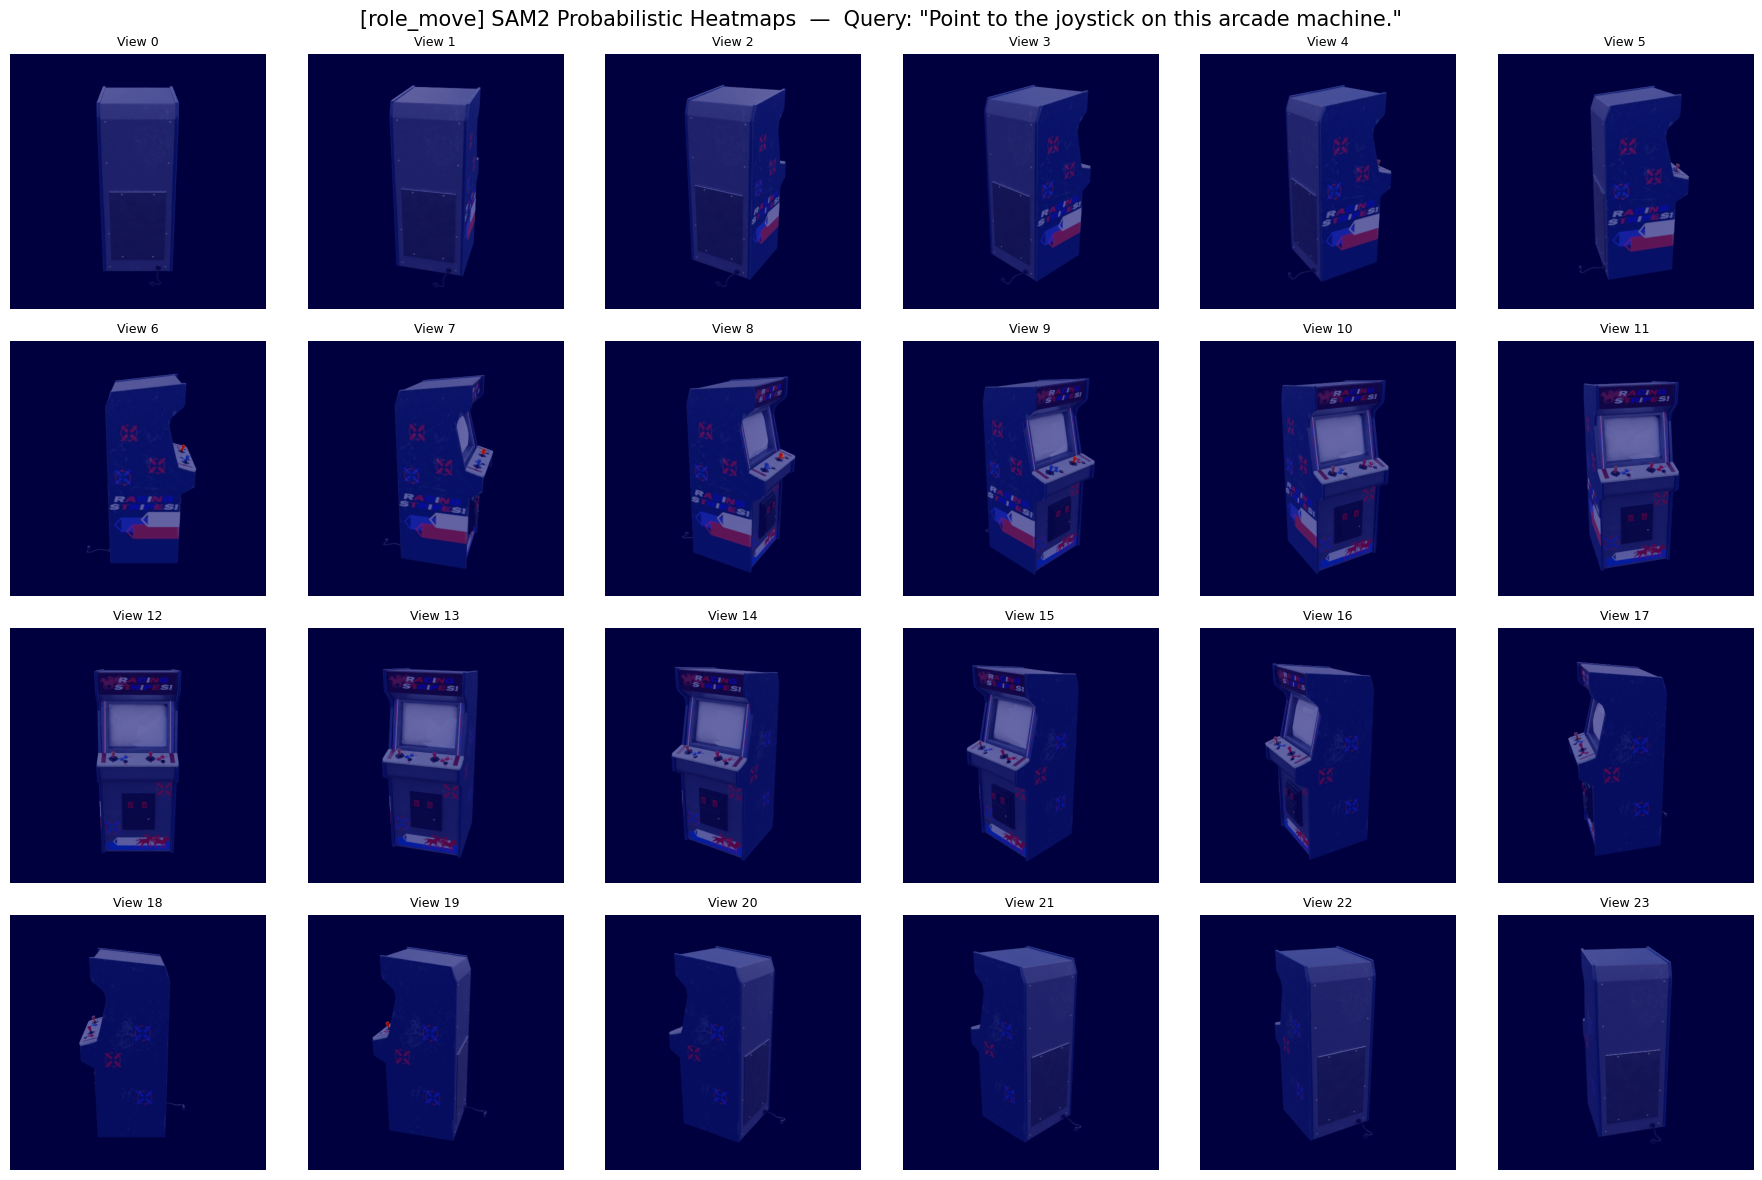

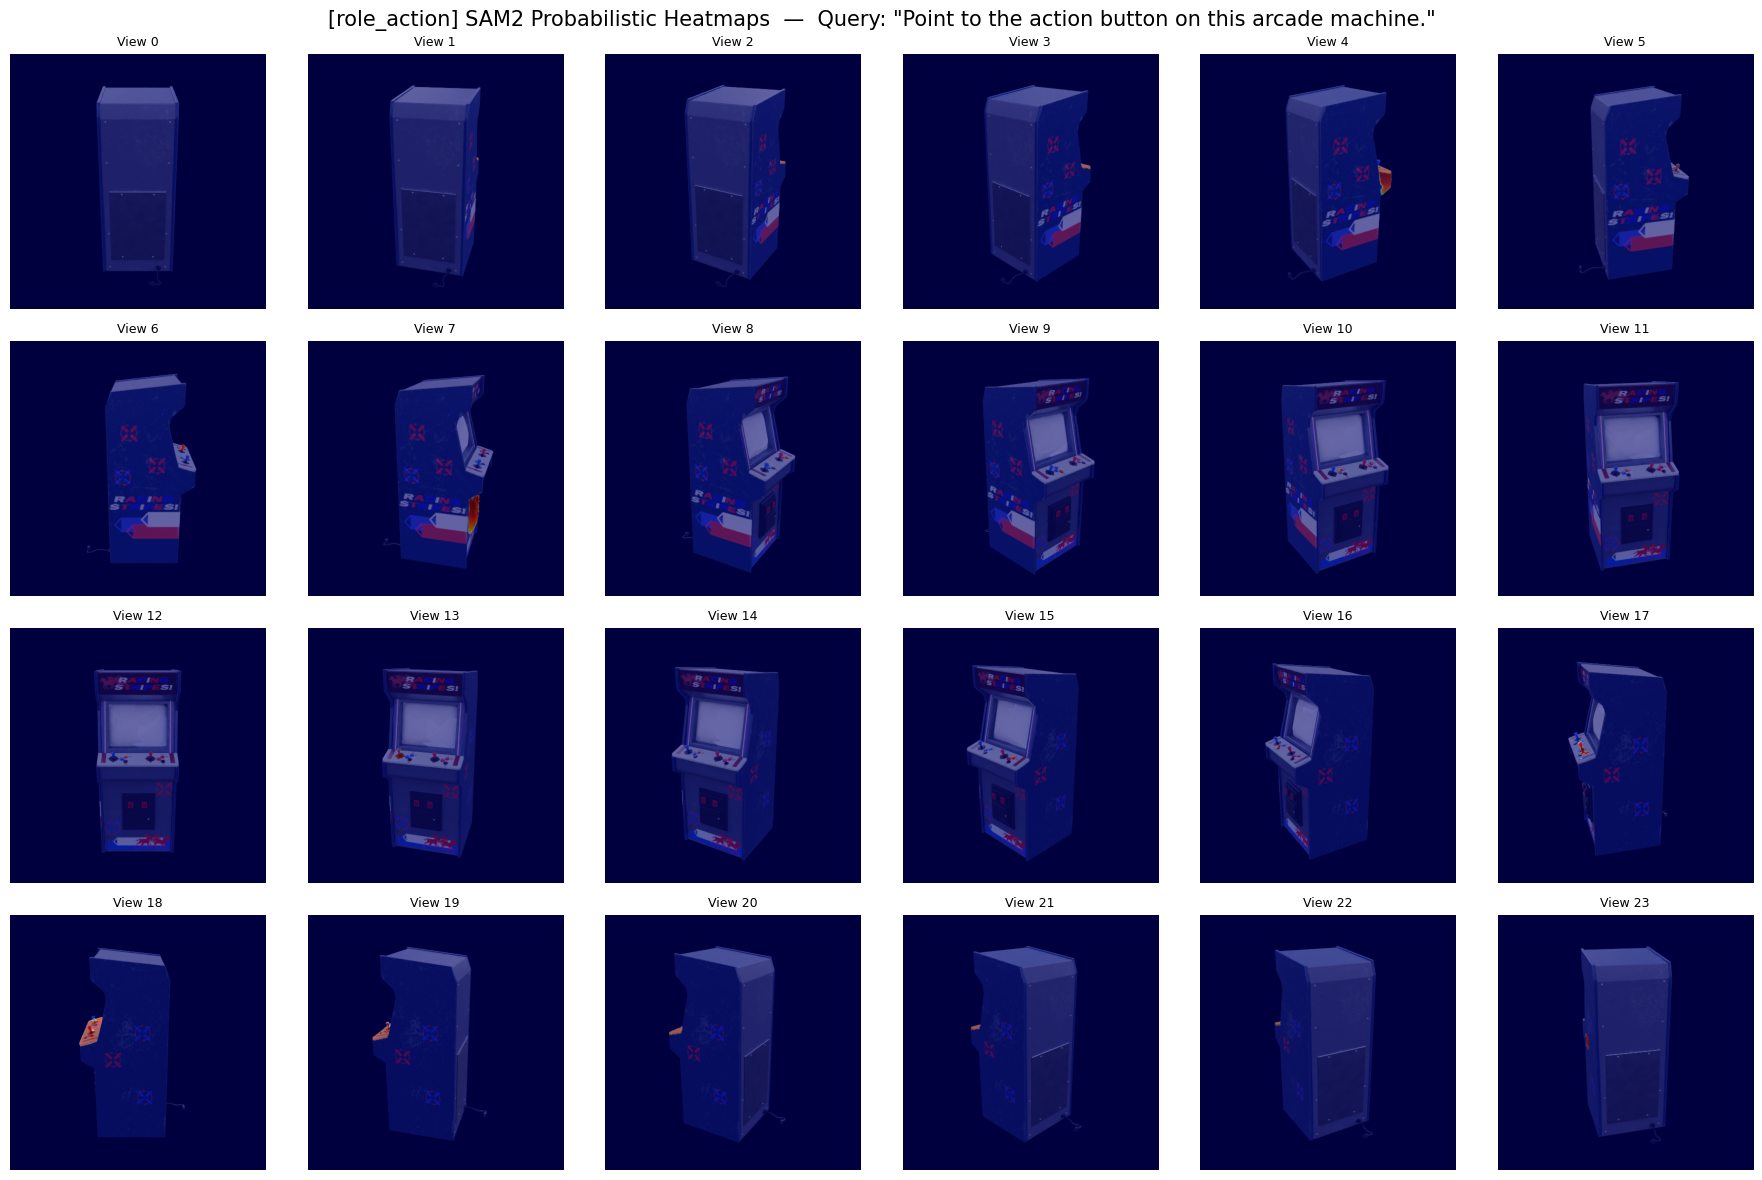

In [17]:
# 視覺化: 每個 role 各畫一張 heatmap overlay grid
for role in ROLES:
    fig, axes = plt.subplots(4, 6, figsize=(18, 12))
    heatmaps = heatmaps_per_view_per_role[role]

    for i, ax in enumerate(axes.flat):
        if i < len(view_images_np):
            ax.imshow(view_images_np[i])
            ax.imshow(heatmaps[i], cmap='jet', alpha=0.5, vmin=0, vmax=1)
            ax.set_title(f'View {i}', fontsize=9)
        ax.axis('off')

    plt.suptitle(f'[{role}] SAM2 Probabilistic Heatmaps  —  Query: "{ROLE_QUERIES[role]}"', fontsize=15)
    plt.tight_layout()
    plt.show()

## Step 14: 多視角 Voting — 把 2D Heatmap 投回原始 3D 點雲

**Affogato 的做法**：
> "We employ a voting-based aggregation process where each view contributes to the final 3D representation, 
> with regions consistently identified across multiple views receiving higher confidence scores."

**實作方式**：
1. 使用 Step 8 產生的**原始點雲** `all_points` 作為 canvas
2. 對每個 3D 點，投影到每個 view 的 2D heatmap 上查值（`P_2d = K @ w2c @ P_3d`）
3. 累加所有能看到這個點的 view 的 heatmap 值，再除以可見 view 數 → **voting average**
4. 結果是原始點雲上的 affordance scores，threshold 後就是原始點雲的子集

### Step 14a: 載入 Ground Truth 點雲 (xyzc.npy)

用 Affogato 提供的原始點雲 `xyzc.npy` 取代 depth 重建的點雲作為投影 canvas。
重建點雲有累積誤差，GT 點雲更精確，投回的 affordance score 會更可靠。

`xyzc.npy` 格式: `[N, C]` — 前 3 欄是 xyz 座標，後面的欄位是不同 query 的 heatmap（不使用）。

In [18]:
# ====== 載入 Ground Truth 點雲 (xyzc.npy) ======
import glob
import plotly.graph_objects as go

npy_files = glob.glob(f'{DATA_ROOT}/xyzc.npy')
assert len(npy_files) > 0, f'No xyzc.npy found in {DATA_ROOT}'
npy_path = npy_files[0]
print(f'Loading GT point cloud: {npy_path}')

gt_data = np.load(npy_path)
print(f'  GT shape: {gt_data.shape}')

# 前 3 欄 = xyz, 後面的欄位是 affordance heatmap (不使用)
gt_points = gt_data[:, :3].astype(np.float32)
gt_colors = np.ones((len(gt_points), 3), dtype=np.float32) * 0.7  # 灰色 placeholder

gt_points = gt_points[:, [0, 2, 1]]  # 先交換 Y 和 Z
gt_points[:, 1] *= -1                 # 只翻轉新的 Y

print(f'  GT bounds:            min={gt_points.min(axis=0)}, max={gt_points.max(axis=0)}')
print(f'  Reconstructed bounds: min={all_points.min(axis=0)}, max={all_points.max(axis=0)}')

# Plotly: 以 affordance score 為顏色
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=gt_points[:, 0],
    y=gt_points[:, 1],
    z=gt_points[:, 2],
    mode='markers',
    marker=dict(
        size=1,
        color=gt_colors,
        # colorscale='Jet',
        cmin=0, cmax=1,
        # colorbar=dict(title='Affordance<br>Score'),
        opacity=0.8,
    ),
    # text=[f'score={s:.3f}, views={c}' for s, c in zip(gt_colors, counts_sub)],
    hoverinfo='text',
    name='3D Affordance'
))

fig.update_layout(
    title=f'Ground Truth Object Point Cloud ({len(gt_points):,} points displayed, subsampled 1/{1})',
    scene=dict(aspectmode='data', xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    width=900, height=700
)

fig.show()

Loading GT point cloud: ./dataset/gobjaverse/electronics/10/62950/xyzc.npy
  GT shape: (16384, 8)
  GT bounds:            min=[-0.27001953 -0.18029785 -0.44995117], max=[0.26953125 0.18029785 0.44995117]
  Reconstructed bounds: min=[-0.89633319 -0.88018714 -0.44725474], max=[0.88587946 0.88364277 0.54735807]


In [19]:
def project_and_sample_heatmaps(points, heatmaps, cameras, K_list, depths, depth_tolerance=0.05):
    """
    把原始 3D 點雲投影到每個 view 的 2D heatmap 上，做 voting aggregation。

    Args:
        points: [N, 3] 原始 3D 點雲 (來自 Step 8)
        heatmaps: list of [H, W] 每個 view 的 2D heatmap
        cameras: list of (c2w, w2c) tuples for each view
        K_list: list of [3, 3] 內參矩陣
        depths: list of [H, W] 深度圖 (用於可見性檢查)
        depth_tolerance: 深度容差 (相對值)，用於判斷點是否被遮擋

    Returns:
        scores: [N] 每個點的 aggregated affordance score
        counts: [N] 每個點被多少個 view 看到
    """
    N = len(points)
    num_views = len(heatmaps)

    score_sum = np.zeros(N, dtype=np.float32)
    view_counts = np.zeros(N, dtype=np.int32)

    points_homo = np.hstack([points, np.ones((N, 1))])  # [N, 4]

    for view_idx in range(num_views):
        c2w, w2c = cameras[view_idx]
        K = K_list[view_idx]
        heatmap = heatmaps[view_idx]
        depth_map = depths[view_idx]
        H, W = heatmap.shape

        cam_coords = (w2c @ points_homo.T).T
        cam_xyz = cam_coords[:, :3]

        in_front = cam_xyz[:, 2] > 0

        pixel_homo = (K @ cam_xyz.T).T
        pixel_uv = pixel_homo[:, :2] / pixel_homo[:, 2:3]

        u = pixel_uv[:, 0]
        v = pixel_uv[:, 1]
        in_bounds = (u >= 0) & (u < W) & (v >= 0) & (v < H)

        proj_depth = cam_xyz[:, 2]

        u_int = np.clip(u.astype(np.int32), 0, W - 1)
        v_int = np.clip(v.astype(np.int32), 0, H - 1)
        sampled_depth = depth_map[v_int, u_int]

        visible = (sampled_depth > 0) & (proj_depth < sampled_depth * (1 + depth_tolerance))

        valid_mask = in_front & in_bounds & visible

        sampled_scores = np.zeros(N, dtype=np.float32)
        sampled_scores[valid_mask] = heatmap[v_int[valid_mask], u_int[valid_mask]]

        score_sum += sampled_scores
        view_counts += valid_mask.astype(np.int32)

    final_scores = np.zeros(N, dtype=np.float32)
    seen_mask = view_counts > 0
    final_scores[seen_mask] = score_sum[seen_mask] / view_counts[seen_mask]

    return final_scores, view_counts


# ====== 準備投影所需的相機參數 (所有 role 共用) ======
cameras = []      # list of (c2w, w2c)
K_list = []
depth_maps = []

for view_idx in tqdm.trange(NUM_VIEWS_TO_LOAD, desc="Preparing camera matrices"):
    json_path = f'{DATA_ROOT}/{view_idx:05d}/{view_idx:05d}.json'
    depth_path = f'{DATA_ROOT}/{view_idx:05d}/{view_idx:05d}_nd.exr'

    c2w = read_camera_matrix(json_path)
    c2w_converted = convert_pose_flip_yz(c2w)
    w2c = np.linalg.inv(c2w_converted)

    camera_pos = c2w[:3, 3]
    depth, _ = read_depth_from_exr(depth_path, camera_pos)

    H, W = depth.shape
    K = get_intrinsic_matrix(H, W)

    cameras.append((c2w, w2c))
    K_list.append(K)
    depth_maps.append(depth)


# ====== Per-role voting aggregation ======
affordance_scores_per_role = {}
visibility_counts_per_role = {}

for role in ROLES:
    print(f"\n=== Voting Aggregation for [{role}] ===")
    print(f"Projecting {len(gt_points):,} GT points to {len(heatmaps_per_view_per_role[role])} views...")
    scores, counts = project_and_sample_heatmaps(
        gt_points,
        heatmaps_per_view_per_role[role],
        cameras, K_list, depth_maps,
        depth_tolerance=0.15,
    )
    affordance_scores_per_role[role] = scores
    visibility_counts_per_role[role] = counts

    print(f"  score range: [{scores.min():.4f}, {scores.max():.4f}]   mean: {scores.mean():.4f}")
    print(f"  visibility:  min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f} views/point")
    print(f"  points seen by 0 views: {(counts == 0).sum():,}")

Preparing camera matrices: 100%|██████████| 24/24 [00:00<00:00, 56.56it/s]



=== Voting Aggregation for [role_move] ===
Projecting 16,384 GT points to 24 views...
  score range: [0.0000, 0.6468]   mean: 0.0015
  visibility:  min=4, max=24, mean=16.7 views/point
  points seen by 0 views: 0

=== Voting Aggregation for [role_action] ===
Projecting 16,384 GT points to 24 views...
  score range: [0.0000, 0.4487]   mean: 0.0078
  visibility:  min=4, max=24, mean=16.7 views/point
  points seen by 0 views: 0


In [20]:
# ====== 3D 視覺化: 每個 role 一張 plot ======
import plotly.graph_objects as go

subsample = 1
idx = np.arange(0, len(gt_points), subsample)
pts_sub = gt_points[idx]
print(f"Subsampled: {len(pts_sub):,} points (1/{subsample})")

for role in ROLES:
    scores_sub = affordance_scores_per_role[role][idx]
    counts_sub = visibility_counts_per_role[role][idx]

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=pts_sub[:, 0],
        y=-pts_sub[:, 1],
        z=-pts_sub[:, 2],
        mode='markers',
        marker=dict(
            size=1,
            color=scores_sub,
            colorscale=ROLE_COLORSCALES[role],
            cmin=0, cmax=1,
            colorbar=dict(title=f'{role}<br>score'),
            opacity=0.85,
        ),
        text=[f'score={s:.3f}, views={c}' for s, c in zip(scores_sub, counts_sub)],
        hoverinfo='text',
        name=role,
    ))
    fig.update_layout(
        title=f'[{role}] Affordance Heatmap  —  Query: "{ROLE_QUERIES[role]}"<br>'
              f'({len(pts_sub):,} points, subsampled 1/{subsample})',
        scene=dict(aspectmode='data', xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
        width=900, height=700,
    )
    fig.show()

Subsampled: 16,384 points (1/1)


### Optional: 點雲清理 (Statistical Outlier Removal)

這一步只在使用 **depth 重建的點雲** 時才需要。Depth 重建會產生空中散射雜點，需要統計離群點移除。
如果使用 **GT 點雲 (`xyzc.npy`)**，資料本身已經乾淨，可以跳過清理直接使用。設定 `CLEAN_POINT_CLOUD = False` 即可跳過。

In [ ]:
# from scipy.spatial import cKDTree

# # ====== Step 1: 清理原始點雲 (移除空中散射雜點) ======
# def remove_statistical_outliers(points, k=20, std_ratio=1.0):
#     """
#     移除統計離群點：計算每個點到 k 近鄰的平均距離，
#     移除距離超過 mean + std_ratio * std 的點。
#     """
#     if len(points) < k + 1:
#         return np.ones(len(points), dtype=bool)
    
#     tree = cKDTree(points)
#     distances, _ = tree.query(points, k=k+1)
#     mean_distances = distances[:, 1:].mean(axis=1)
    
#     threshold = mean_distances.mean() + std_ratio * mean_distances.std()
#     inlier_mask = mean_distances < threshold
#     return inlier_mask

# print("Cleaning base point cloud (removing scattered noise)...")
# base_inlier_mask = remove_statistical_outliers(gt_points, k=20, std_ratio=1.0)
# all_points_clean = gt_points[base_inlier_mask]
# all_colors_clean = gt_colors[base_inlier_mask]
# affordance_scores_clean = affordance_scores[base_inlier_mask]
# visibility_counts_clean = visibility_counts[base_inlier_mask]

# n_base_removed = len(gt_points) - len(all_points_clean)
# print(f"Base cloud: {n_base_removed:,} noise points removed "
#       f"({n_base_removed/len(gt_points)*100:.1f}%), "
#       f"{len(all_points_clean):,} remaining")

In [ ]:
# ====== 高分區域視覺化: 灰色底圖 + 各 role 用不同顏色的高分點 ======
all_points_clean = gt_points

SCORE_THRESHOLD = 0.15
MIN_VIEWS = 2

fig = go.Figure()

# 灰色底圖
subsample = 1
bg_idx = np.arange(0, len(all_points_clean), subsample)
fig.add_trace(go.Scatter3d(
    x=all_points_clean[bg_idx, 0],
    y=all_points_clean[bg_idx, 1],
    z=all_points_clean[bg_idx, 2],
    mode='markers',
    marker=dict(size=1, color='gray', opacity=0.25),
    hoverinfo='skip',
    name='object',
))

# 每個 role 加一個 high-score trace
for role in ROLES:
    scores = affordance_scores_per_role[role]
    counts = visibility_counts_per_role[role]
    high_mask = (scores >= SCORE_THRESHOLD) & (counts >= MIN_VIEWS)

    n_high = int(high_mask.sum())
    print(f"[{role}] high-score (score >= {SCORE_THRESHOLD}, views >= {MIN_VIEWS}): "
          f"{n_high:,} / {len(scores):,} ({n_high/len(scores)*100:.1f}%)")

    if n_high == 0:
        continue

    high_pts = all_points_clean[high_mask]
    high_scs = scores[high_mask]

    fig.add_trace(go.Scatter3d(
        x=high_pts[:, 0],
        y=high_pts[:, 1],
        z=high_pts[:, 2],
        mode='markers',
        marker=dict(size=1, color=ROLE_COLORS[role], opacity=0.9),
        text=[f'{role}: score={s:.3f}' for s in high_scs],
        hoverinfo='text',
        name=role,
    ))

queries_str = "<br>".join(f'<b>[{r}]</b> "{ROLE_QUERIES[r]}"' for r in ROLES)
fig.update_layout(
    title=dict(text=queries_str, x=0.5, xanchor="center", font=dict(size=12)),
    scene=dict(aspectmode='data', xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    width=900, height=700,
    showlegend=True,
)
fig.show()

## Step 15: 儲存點雲為 xyzc.npy

儲存清理後的點雲為 Affogato dataset 格式 (`xyzc.npy`):
- Shape: `[N, 6]`
- `[:, :3]` = xyz 座標
- `[:, 3:6]` = RGB 顏色 (0~1)

In [ ]:
# # ====== 儲存清理後的點雲為 xyzc.npy ======
# def save_point_cloud_xyzc(filename, points, colors):
#     """
#     將點雲儲存為 Affogato dataset 格式 (xyzc.npy)
    
#     Args:
#         filename: 輸出檔案路徑
#         points: [N, 3] xyz 座標
#         colors: [N, 3] RGB 顏色 (0~1 或 0~255)
#     """
#     # 確保顏色在 0~1 範圍
#     if colors.max() > 1.0:
#         colors = colors / 255.0
    
#     # 組合成 [N, 6] array: [x, y, z, r, g, b]
#     xyzc = np.concatenate([points, colors], axis=1)
    
#     np.save(filename, xyzc)
#     print(f"✅ Saved {len(points):,} points to {filename}")
#     print(f"   Shape: {xyzc.shape}, dtype: {xyzc.dtype}")


# # 儲存點雲
# output_path = "./xyzc.npy"
# save_point_cloud_xyzc(output_path, all_points_clean, all_colors_clean)
# print(f"\n可以用 code/read_npy.py 檢視點雲：")
# print(f"  python ../code/read_npy.py {output_path}")